In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns",None)

In [3]:
sns.set_style('whitegrid')

In [4]:
df = pd.read_csv("german_credit_data.csv")

In [5]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [6]:
df = df.drop(columns= ["Unnamed: 0"])
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [7]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [8]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [9]:
df.shape

(1000, 10)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


In [11]:
df.describe(include="all")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


In [12]:
df["Job"].unique()
# there are three types of jobs

array([2, 1, 3, 0])

In [13]:
df.isna().sum() 

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

There are missing values in columns "Svaing accounts" and "Checking accounts' ie 183 and 394 respectively.

In [14]:
#Checking For Duplicates
df.duplicated().sum()


np.int64(0)

There are no duplicate values

## Examing the null values

In [15]:
df_na= df[df[["Saving accounts","Checking account"]].isnull().any(axis=1)]


In [16]:
df_na.shape

(478, 10)

In [17]:
df_na.describe(include="all")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,478.000000,478,478.000000,478,295,84,478.000000,478.000000,478,478
unique,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,male,NaN,own,little,moderate,NaN,NaN,car,good
freq,NaN,336,NaN,364,191,45,NaN,NaN,164,409
mean,36.263598,NaN,1.935146,NaN,NaN,NaN,3263.081590,20.426778,NaN,NaN
std,10.874237,NaN,0.619375,NaN,NaN,NaN,2704.782794,11.582621,NaN,NaN
min,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,28.000000,NaN,2.000000,NaN,NaN,NaN,1429.000000,12.000000,NaN,NaN
50%,35.000000,NaN,2.000000,NaN,NaN,NaN,2290.000000,18.000000,NaN,NaN
75%,42.000000,NaN,2.000000,NaN,NaN,NaN,3957.500000,24.000000,NaN,NaN


In [18]:
df_na["Risk"].value_counts()

Risk
good    409
bad      69
Name: count, dtype: int64

In [19]:
df_na["Sex"].value_counts()

Sex
male      336
female    142
Name: count, dtype: int64

### Findings about missing values 
- There are total of 478 rows that contain missing values.
- Large amount of missing values are of the people having value good in Risk columns i.e. 409.
- The majority of missing values rows Sex is Male. i.e. 336.

### Measures we took to tackle missing values
"Saving account" and "Checking accounts" columns are important for our anylsis, So we cant drop these columns.<br>
The options we have are:
- impute null values 
- drop null values

The Methadolodgy, I'll use in this scenario
<br>I am  gonna take the second approch, I will drop the rows containing null values.

In [20]:
df = df.dropna().reset_index(drop= True)
df


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


In [21]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

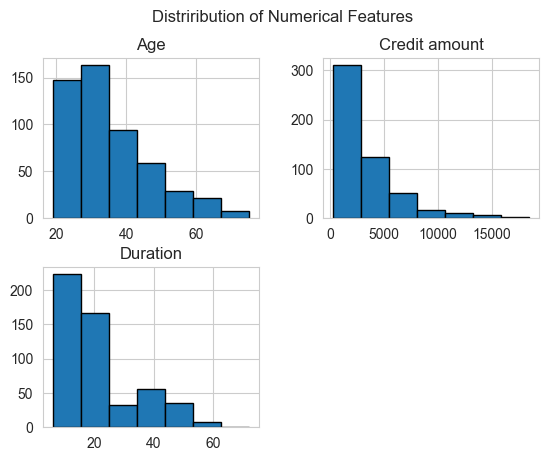

In [22]:
df[["Age","Credit amount","Duration"]].hist(bins=7, edgecolor = "black")
plt.suptitle("Distriribution of Numerical Features", fontsize = 12)
plt.show()

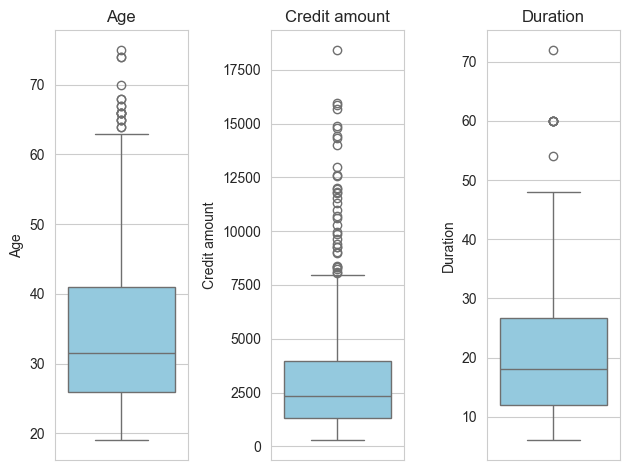

In [23]:
plt.Figure(figsize=(10,10))
for i,col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1, 3,i + 1)
    sns.boxplot(y=df[col],color="skyblue")
    plt.title(col)
plt.tight_layout()
plt.show()


In [24]:
# df[df["Duration"] >= 60]
df.query("Duration >=  60")


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [25]:
categorical_cols = ["Sex","Job","Housing","Saving accounts","Checking account","Purpose"]

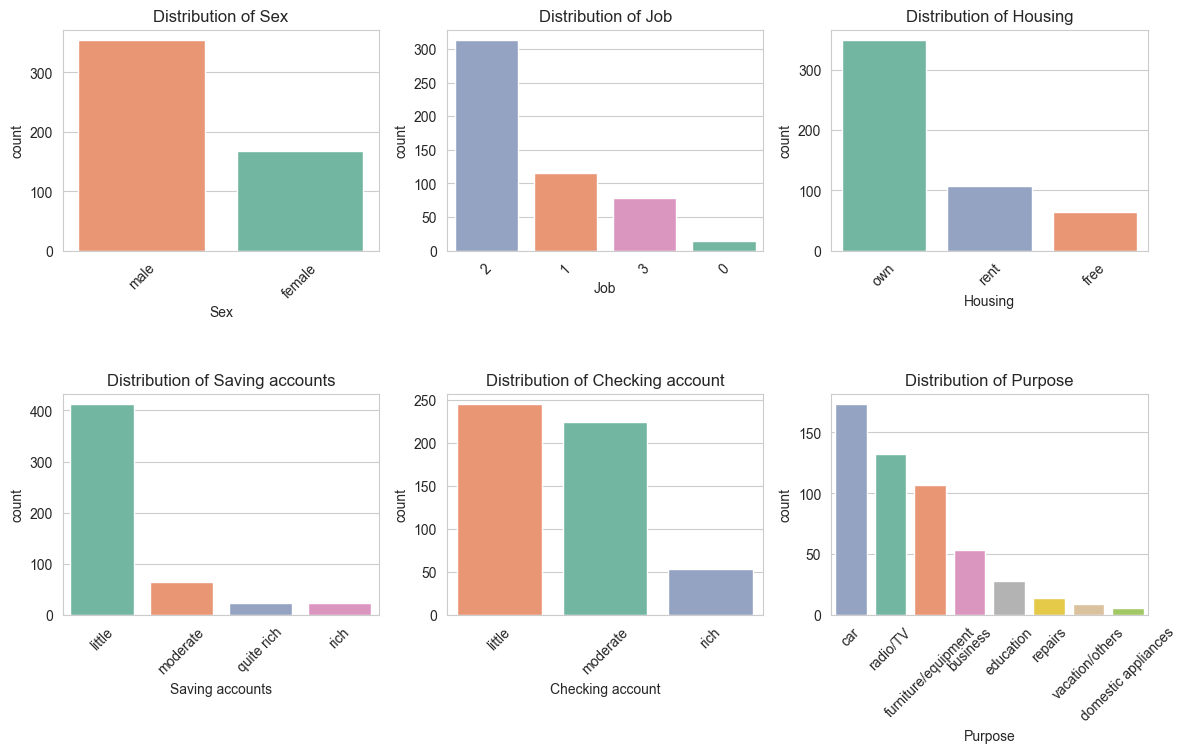

In [26]:
plt.figure(figsize=(12,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df,x=col,hue=col ,legend=False,palette="Set2",order = df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
corr = df[["Age","Job","Credit amount","Duration"]].corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


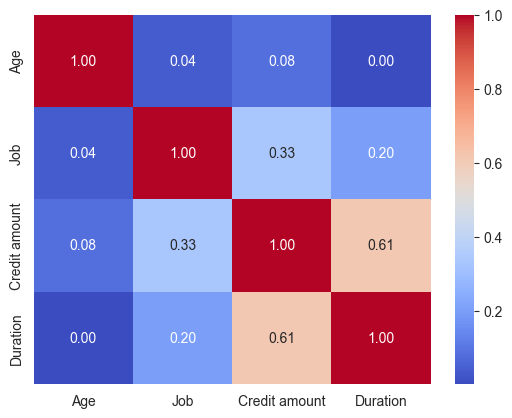

In [28]:
sns.heatmap(corr,annot= True,cmap="coolwarm",fmt=".2f")
plt.show()


From this Heatmap we can interpret that there is no such correalation between the variable. The only highest value we can witness is 0.61
between "Credit amunt" and "Duration".

In [29]:
df["Credit amount"].groupby(df["Job"]).mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [30]:
df["Credit amount"].groupby(df["Sex"]).mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [31]:
pd.pivot_table(df,values="Credit amount",index="Housing",columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


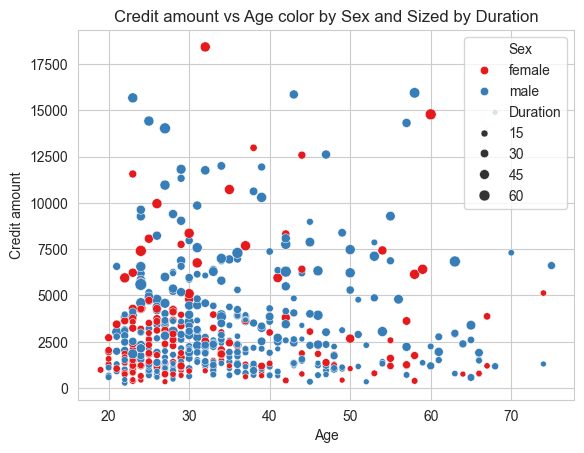

In [32]:
sns.scatterplot(df,x="Age", y="Credit amount",hue="Sex",size="Duration",palette="Set1")
plt.title("Credit amount vs Age color by Sex and Sized by Duration")
plt.show()

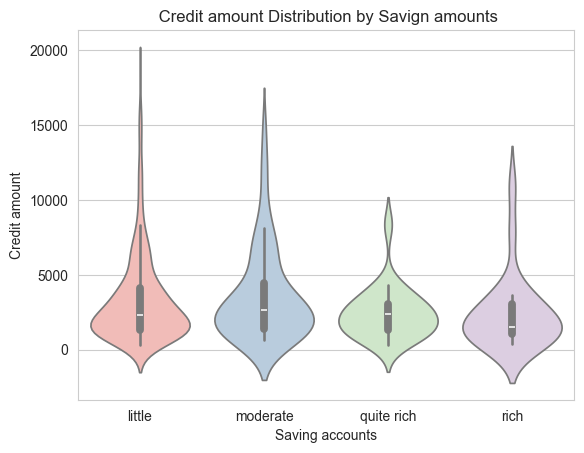

In [33]:
sns.violinplot(data=df,x="Saving accounts",y="Credit amount",hue="Saving accounts",palette="Pastel1")
plt.title(" Credit amount Distribution by Savign amounts")
plt.show()

In [34]:
df["Risk"].value_counts(normalize=True)*100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

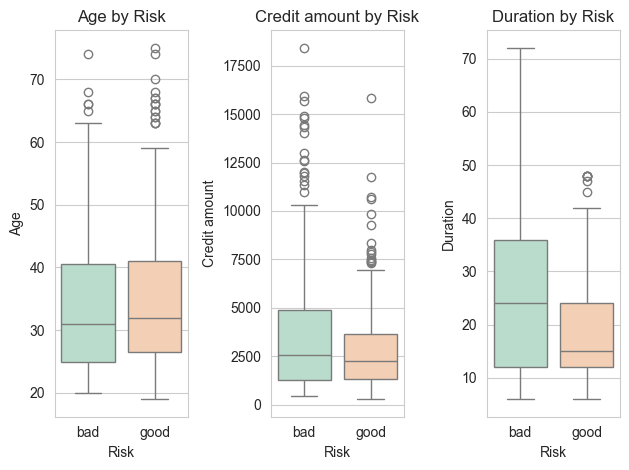

In [35]:
plt.Figure(figsize=(8,4))
for i,col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df,x="Risk",y=col, hue="Risk",palette="Pastel2")
    plt.title(f"{col} by Risk")
plt.tight_layout()
plt.show()

In [36]:
df[["Age","Credit amount","Duration"]].groupby(df["Risk"]).mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


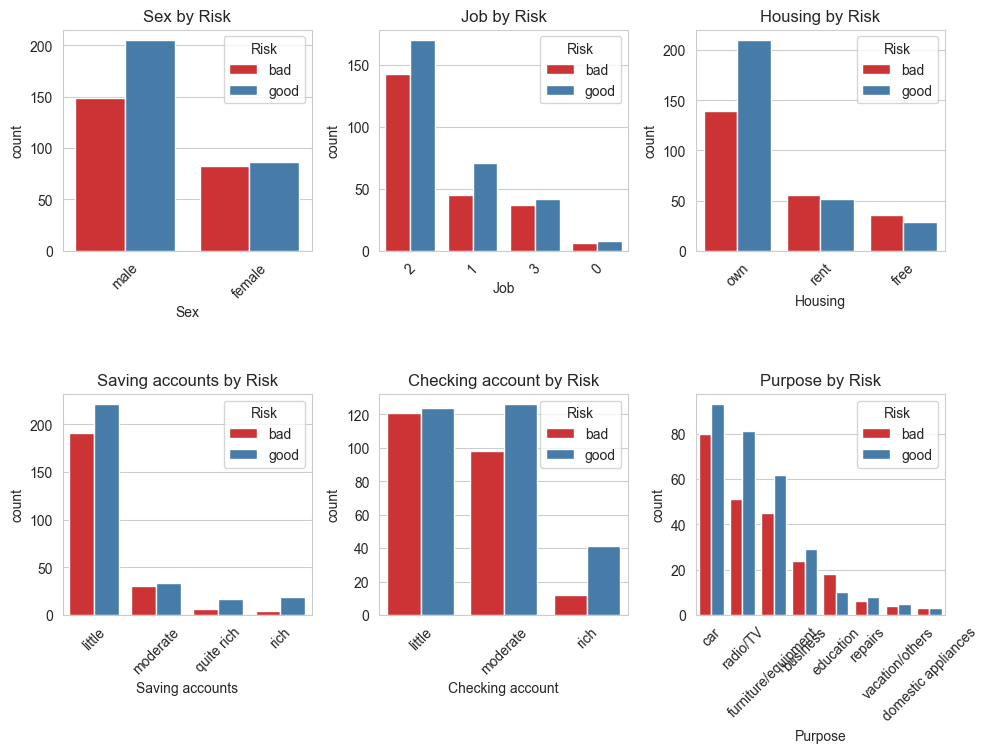

In [37]:
plt.figure(figsize=(10,10))
for i,col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df,x=col,hue="Risk",palette="Set1",hue_order=["bad","good"],order=df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [38]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [39]:
features=["Age","Sex","Job","Housing","Saving accounts","Checking account","Credit amount","Duration"]

In [40]:
target= "Risk"

In [41]:
df_model =df[features + [target]].copy()

In [42]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [43]:
from sklearn.preprocessing import LabelEncoder
import joblib



In [44]:
cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")

C:\Users\wahab\AppData\Local\Temp\ipykernel_9172\714141096.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")


In [45]:
le_dict ={}

In [46]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')

In [47]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col]=le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le,f"{col}_encoder.pkl")

In [48]:
le_target = LabelEncoder()

In [49]:
target

'Risk'

In [50]:
df_model[target] =le_target.fit_transform(df_model[target])

In [51]:
df_model[target]

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [52]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [53]:
joblib.dump(le_target,"target_encoder.pkl")

['target_encoder.pkl']

In [54]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [55]:
from sklearn.model_selection import train_test_split

In [56]:
X = df_model.drop(target,axis= 1)

In [57]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [58]:
y=df_model[target]

In [59]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [60]:
X_train,X_test , y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state= 1)

In [61]:
X_train.shape

(417, 8)

In [62]:
X_test.shape

(105, 8)

In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [64]:
def train_model(model,param_grid,X_train,y_train,X_test,y_test):
    grid = GridSearchCV(model,param_grid,cv=5,scoring="accuracy",n_jobs= -1)
    grid.fit(X_train,y_train)
    best_model=grid.best_estimator_
    y_pred= best_model.predict(X_test)
    acc= accuracy_score(y_test,y_pred)
    return best_model,acc,grid.best_params_

In [65]:
dt = DecisionTreeClassifier(random_state=1,class_weight="balanced")
dt_param_grid ={
    "max_depth" : [3,5,7,10,None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" :[1,2,4]
}

In [67]:
best_dt,acc_dt,params_dt =train_model(dt,dt_param_grid,X_train,y_train,X_test,y_test)

In [68]:
print("Desicion Tree Acurracy",acc_dt)

Desicion Tree Acurracy 0.580952380952381


In [69]:
print("Best parameters",params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
rf = RandomForestClassifier(random_state=1,class_weight="balanced",n_jobs=-1)

In [73]:
rf_param_grid = {
    "n_estimators" :[100,200],
    "max_depth" :[5,7,10,None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" :[1,2,4]



}

In [74]:
best_rf,acc_rf,params_rf, = train_model(rf,rf_param_grid,X_train,y_train,X_test,y_test)

In [75]:
print("Random Forest Accuracy", acc_rf)

Random Forest Accuracy 0.6190476190476191


In [77]:
print("Best Parameters",params_rf)

Best Parameters {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [79]:
et = ExtraTreesClassifier(random_state=1,class_weight='balanced',n_jobs=-1)

In [80]:
et_param_grid = {
    "n_estimators" :[100,200],
    "max_depth" :[5,7,10,None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" :[1,2,4]



}

In [81]:
best_et,acc_et,params_et =train_model(et,et_param_grid,X_train,y_train,X_test,y_test)

In [82]:
print("Extra trees accuracy",acc_et)

Extra trees accuracy 0.6476190476190476


In [83]:
print("Best params",params_et)

Best params {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [91]:
xgb = XGBClassifier(random_state =1 , scale_pos_weight= (y_train==0).sum()/(y_train==1).sum(),use_label_encoder = False, eval_metric ="logloss")

In [92]:
xgb_param_grid ={
    "n_estimators" : [100,200],
    "max_depth" :[3,5,7],
    "learning_rate" : [0.01,0.1,0.2],
    "subsample" : [0.7,1],
    "colsample_bytree" : [0.7,1]
}

In [93]:
best_xgb,acc_xgb,params_xgb = train_model(xgb,xgb_param_grid,X_train,y_train,X_test,y_test)

c:\Users\wahab\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:16:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [94]:
print("XGB accuracy",acc_xgb)

XGB accuracy 0.6761904761904762


In [96]:
print("Best params",params_xgb)

Best params {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}


In [98]:
best_et.predict(X_test)

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1])

In [99]:
joblib.dump(best_et,"extra_trees_credit_model.pkl")

['extra_trees_credit_model.pkl']

In [100]:
df.columns


Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')